# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('/Users/jacobpaul/Documents/Springboard-bootcamp/GitHub/frequentist-Inference-case-study-/insurance2.csv')

In [8]:
medical.shape

(1338, 8)

In [10]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

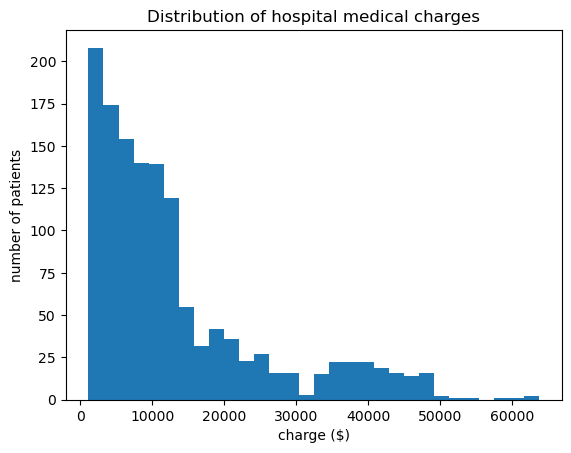

In [12]:
_ = plt.hist(medical.charges, bins=30)
_ = plt.xlabel('charge ($)')
_ = plt.ylabel('number of patients')
_ = plt.title('Distribution of hospital medical charges')

In [14]:
charges_mean = np.mean(medical.charges)
charges_std = np.std(medical.charges, ddof=1)
print('Mean charge: ${:.2f}'.format(charges_mean))
print('Std charge: ${:.2f}'.format(charges_std))

Mean charge: $13270.42
Std charge: $12110.01


__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__ Even though the individual charges are not normally distributed, the Central Limit Theorem tells us that the **sampling distribution of the mean** will be approximately normal, given our reasonably large sample size ($n=1338$). This justifies using the sample mean and standard deviation to make inferences about the true population mean charge, and to construct a confidence interval / hypothesis test around it.

Since we don't know the true population standard deviation and must estimate it from the sample, the most appropriate test is a **one-sample *t*-test** on the mean (equivalently, a *t*-based confidence interval for the mean), rather than a *z*-test (which would require a known population standard deviation).

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ The administrator is only concerned about the average charge being *too low* (below \$12,000) — there's no stated concern about it being unusually high. This means a **one-sided (lower-tailed)** 95% confidence interval is appropriate: we want a single lower bound below which we're 95% confident the true mean does not fall.

In [18]:
n = len(medical.charges)
t_critical = t.ppf(0.95, df=n - 1)  # one-sided 95% -> 95th percentile, not 97.5th
print('Sample size:', n)
print('Critical t value (one-sided, 95%):', t_critical)

Sample size: 1338
Critical t value (one-sided, 95%): 1.6459941145571317


In [20]:
standard_error = charges_std / np.sqrt(n)
margin_of_error = t_critical * standard_error
lower_bound = charges_mean - margin_of_error
print('Standard error:', standard_error)
print('Margin of error:', margin_of_error)
print('One-sided 95% CI lower bound: ${:.2f}'.format(lower_bound))

Standard error: 331.06745431568226
Margin of error: 544.9350813250251
One-sided 95% CI lower bound: $12725.49


The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ * **Null hypothesis ($H_0$):** People with insurance are charged the same average amount as people without insurance (i.e., $\mu_{insured} = \mu_{uninsured}$, so the true difference in means is 0).
* **Alternative hypothesis ($H_1$):** People with insurance are charged a different average amount than people without insurance ($\mu_{insured} \ne \mu_{uninsured}$) — this is a two-sided test, since we have no prior reason to assume the direction of any difference.

This pooled-standard-deviation formula assumes that the two groups have **equal population variances** (homogeneity of variance / homoscedasticity), even though their means may differ.

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [22]:
insured = medical.charges[medical.insuranceclaim == 1]
uninsured = medical.charges[medical.insuranceclaim == 0]

n0, n1 = len(uninsured), len(insured)
mean0, mean1 = np.mean(uninsured), np.mean(insured)
std0, std1 = np.std(uninsured, ddof=1), np.std(insured, ddof=1)

print('Uninsured: n = {}, mean = {:.2f}, std = {:.2f}'.format(n0, mean0, std0))
print('Insured:   n = {}, mean = {:.2f}, std = {:.2f}'.format(n1, mean1, std1))

Uninsured: n = 555, mean = 8821.42, std = 6446.51
Insured:   n = 783, mean = 16423.93, std = 14045.93


In [24]:
# Manual calculation
sp = np.sqrt(((n0 - 1) * std0**2 + (n1 - 1) * std1**2) / (n0 + n1 - 2))
t_stat_manual = (mean0 - mean1) / (sp * np.sqrt(1/n0 + 1/n1))
print('Pooled standard deviation:', sp)
print('Manual t-statistic:', t_stat_manual)

Pooled standard deviation: 11520.034268775256
Manual t-statistic: -11.893299030876715


In [26]:
df = n0 + n1 - 2
p_value_manual = 2 * t.cdf(-abs(t_stat_manual), df)
print('Degrees of freedom:', df)
print('Manual p-value:', p_value_manual)

Degrees of freedom: 1336
Manual p-value: 4.4612302316205886e-31


In [28]:
from scipy.stats import ttest_ind
t_stat_scipy, p_value_scipy = ttest_ind(uninsured, insured)
print('scipy t-statistic:', t_stat_scipy)
print('scipy p-value:', p_value_scipy)

scipy t-statistic: -11.893299030876712
scipy p-value: 4.461230231620717e-31


In [31]:
print('t-statistics match:', np.isclose(t_stat_manual, t_stat_scipy))
print('p-values match:', np.isclose(p_value_manual, p_value_scipy))

t-statistics match: True
p-values match: True


Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ No — `scipy.stats` does not provide a dedicated *z*-test function for comparing sample means (there's no `ztest` alongside `ttest_ind`/`ttest_1samp`). This makes sense: a *z*-test requires the **true population standard deviation** to be known in advance, which is rarely the case in real-world data analysis. Since we almost always have to *estimate* the standard deviation from the sample itself, the *t*-test (which accounts for that extra uncertainty via the *t*-distribution) is the appropriate and far more commonly needed tool — so it's the one scipy provides directly. (A z-test can still be found elsewhere, e.g. `statsmodels.stats.weightstats.ztest`, for the less common cases where the population standard deviation genuinely is known.)

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test